In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
df = pd.read_csv(r"E:\Mhmd tn\Stores_Data\Dataset.csv")
df.head()

,Store ID,City,State,Sales Region,New Expansion,Marketing Spend,Revenue
0,1,Peoria,Arizona,Region 2,Old,2601,48610
1,2,Midland,Texas,Region 2,Old,2727,45689
2,3,Spokane,Washington,Region 2,Old,2768,49554
3,4,Denton,Texas,Region 2,Old,2759,38284
4,5,Overland Park,Kansas,Region 2,Old,2869,59887


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Store ID         150 non-null    int64 
 1   City             150 non-null    object
 2   State            150 non-null    object
 3   Sales Region     150 non-null    object
 4   New Expansion    150 non-null    object
 5   Marketing Spend  150 non-null    int64 
 6   Revenue          150 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 8.3+ KB


In [41]:
df[['Marketing Spend' , 'Revenue']].describe().round(2)

,Marketing Spend,Revenue
count,150.00,150.00
mean,2986.73,44572.61
std,582.73,14445.56
min,2007.00,20403.00
25%,2465.00,32755.00
50%,2952.50,42725.50
75%,3537.00,59406.75
max,3983.00,69744.00


Check

In [42]:
df['City'].unique()

array(['Peoria', 'Midland', 'Spokane', 'Denton', 'Overland Park',
       'Jacksonville', 'Milwaukee', 'Fresno', 'Memphis', 'Atlanta',
       'San Diego', 'Louisville', 'Chicago', 'Long Beach', 'Tucson',
       'Phoenix', 'Oakland', 'Houston', 'Columbus', 'Omaha', 'San Jose',
       'Mesa', 'Philadelphia', 'Las Vegas', 'New Orleans', 'Arlington',
       'Dallas', 'El Paso', 'Detroit', 'Denver', 'Tulsa', 'Los Angeles',
       'Fort Worth', 'New York City', 'San Antonio', 'Nashville',
       'Minneapolis', 'Sacramento', 'Colorado Springs', 'Miami',
       'Baltimore', 'Charlotte', 'Oklahoma City', 'Raleigh', 'Washington',
       'Albuquerque', 'Austin', 'San Francisco', 'Virginia Beach',
       'Kansas City', 'Indianapolis', 'Paterson', 'Brownsville',
       'Rockford', 'College Station', 'Thousand Oaks'], dtype=object)

In [43]:
df['State'].value_counts()

State
Texas                   29
California              24
Arizona                 13
North Carolina           8
Oklahoma                 8
Florida                  7
Illinois                 6
Louisiana                6
Nevada                   6
Tennessee                4
Pennsylvania             4
Kentucky                 3
Maryland                 3
Georgia                  3
New York                 3
Ohio                     3
Wisconsin                2
Michigan                 2
Colorado                 2
Nebraska                 2
Minnesota                2
New Mexico               2
Indiana                  2
Kansas                   1
Washington               1
District of Columbia     1
Virginia                 1
Missouri                 1
New Jersey               1
Name: count, dtype: int64

In [44]:
df['State'].nunique()

29

In [45]:
df['City'].value_counts()

City
Las Vegas           6
New Orleans         6
Houston             6
San Diego           5
Chicago             5
Phoenix             5
Jacksonville        5
Raleigh             5
Tulsa               4
El Paso             4
San Antonio         4
Tucson              4
Los Angeles         4
Oakland             4
Oklahoma City       4
Philadelphia        4
Mesa                3
Fort Worth          3
New York City       3
Dallas              3
Austin              3
Baltimore           3
Fresno              3
Long Beach          3
Charlotte           3
Louisville          3
Atlanta             3
Columbus            3
Nashville           2
Minneapolis         2
Miami               2
Detroit             2
Indianapolis        2
Arlington           2
San Jose            2
Omaha               2
Memphis             2
Milwaukee           2
Albuquerque         2
Paterson            1
Kansas City         1
Virginia Beach      1
Brownsville         1
Rockford            1
College Station     1
San F

In [46]:
df['Sales Region'].value_counts()

Sales Region
Region 2    82
Region 1    68
Name: count, dtype: int64

In [47]:
df['New Expansion'].value_counts()

New Expansion
Old    89
New    61
Name: count, dtype: int64

In [48]:
df.isnull().sum()

Store ID           0
City               0
State              0
Sales Region       0
New Expansion      0
Marketing Spend    0
Revenue            0
dtype: int64

In [49]:
df.duplicated().sum()

0

In [50]:
df.dtypes

Store ID            int64
City               object
State              object
Sales Region       object
New Expansion      object
Marketing Spend     int64
Revenue             int64
dtype: object

<Axes: xlabel='Revenue'>

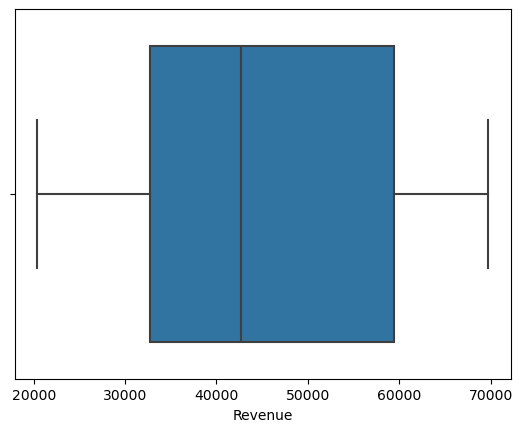

In [51]:
import seaborn as sns
sns.boxplot(x=df['Revenue'])

Analysing Data

In [52]:
df.sample(10)

,Store ID,City,State,Sales Region,New Expansion,Marketing Spend,Revenue
31,32,New Orleans,Louisiana,Region 1,New,2186,42491
37,38,New Orleans,Louisiana,Region 1,New,3552,33498
142,143,Indianapolis,Indiana,Region 1,Old,3857,40027
47,48,San Diego,California,Region 2,Old,2738,32311
62,63,New Orleans,Louisiana,Region 2,New,3931,42882
3,4,Denton,Texas,Region 2,Old,2759,38284
70,71,Sacramento,California,Region 2,New,2102,24896
126,127,Virginia Beach,Virginia,Region 1,New,2241,39000
110,111,Baltimore,Maryland,Region 2,Old,3835,47356
98,99,Minneapolis,Minnesota,Region 2,Old,3342,35000


In [53]:
df['Profit'] = df['Revenue'] - df['Marketing Spend']
df

,Store ID,City,State,Sales Region,New Expansion,Marketing Spend,Revenue,Profit
0,1,Peoria,Arizona,Region 2,Old,2601,48610,46009
1,2,Midland,Texas,Region 2,Old,2727,45689,42962
2,3,Spokane,Washington,Region 2,Old,2768,49554,46786
3,4,Denton,Texas,Region 2,Old,2759,38284,35525
4,5,Overland Park,Kansas,Region 2,Old,2869,59887,57018
...,...,...,...,...,...,...,...,...
145,146,Paterson,New Jersey,Region 1,New,2251,34603,32352
146,147,Brownsville,Texas,Region 2,New,3675,63148,59473
147,148,Rockford,Illinois,Region 1,New,2648,43377,40729
148,149,College Station,Texas,Region 2,New,2994,22457,19463


In [54]:
df[df['New Expansion'] == 'Old'].groupby(['State']).max()['Profit'].sort_values(ascending=False)

State
Louisiana               67468
Colorado                66944
Florida                 65995
Oklahoma                64119
Indiana                 63850
California              63531
Tennessee               63447
Texas                   63171
Kentucky                62306
Nebraska                62261
District of Columbia    61911
Arizona                 61348
Kansas                  57018
Maryland                54266
Minnesota               46834
Washington              46786
Michigan                44637
Nevada                  44337
Illinois                39116
New York                36519
Ohio                    34175
Pennsylvania            33780
New Mexico              29246
North Carolina          19082
Name: Profit, dtype: int64

In [55]:
df[df['New Expansion'] == 'New'].groupby(['State']).max()['Profit'].sort_values(ascending=False)

State
Illinois          67001
Texas             65428
Nevada            63559
Arizona           63252
Georgia           62403
North Carolina    60865
Oklahoma          59960
Ohio              59729
California        58323
New Mexico        52033
Pennsylvania      50846
Wisconsin         50376
Missouri          43173
Florida           41666
Louisiana         40305
Virginia          36759
Maryland          35766
New Jersey        32352
New York          31468
Name: Profit, dtype: int64

In [56]:
top10_profit = df[['Store ID','City','State','Profit']].sort_values(by='Profit', ascending=False).head(10)
top10_profit

,Store ID,City,State,Profit
120,121,New Orleans,Louisiana,67468
53,54,Chicago,Illinois,67001
77,78,Colorado Springs,Colorado,66944
87,88,Miami,Florida,65995
64,65,San Antonio,Texas,65428
124,125,Oklahoma City,Oklahoma,64119
131,132,Indianapolis,Indiana,63850
83,84,Las Vegas,Nevada,63559
69,70,San Diego,California,63531
8,9,Memphis,Tennessee,63447


In [57]:
# حساب متوسط الربح لكل Store
store_profit = df.groupby('Store ID')['Profit'].mean()

# أعلى Store
max_store = store_profit.idxmax()
print("Highest Profit Store:", max_store, "Profit:", store_profit[max_store])

# أقل Store
min_store = store_profit.idxmin()
print("Lowest Profit Store:", min_store, "Profit:", store_profit[min_store])


Highest Profit Store: 121 Profit: 67468.0
Lowest Profit Store: 12 Profit: 16647.0


In [58]:
# أعلى فرع من حيث الربح
max_profit_store = df.loc[df['Profit'].idxmax()]
print("Highest Profit Store:")
print(max_profit_store)

# أقل فرع من حيث الربح
min_profit_store = df.loc[df['Profit'].idxmin()]
print("\nLowest Profit Store:")
print(min_profit_store)



Highest Profit Store:
Store ID                   121
City               New Orleans
State                Louisiana
Sales Region          Region 2
New Expansion              Old
Marketing Spend           2276
Revenue                  69744
Profit                   67468
Name: 120, dtype: object

Lowest Profit Store:
Store ID                 12
City                Atlanta
State               Georgia
Sales Region       Region 2
New Expansion           New
Marketing Spend        3900
Revenue               20547
Profit                16647
Name: 11, dtype: object


In [59]:
#هل فى علاقة بين الانفاق التسويقى والايرادات
correlation = df['Marketing Spend'].corr(df['Revenue'])
print("Correlation:", correlation)

Correlation: -0.07911317679214637


In [60]:
# هل الفروع الجديدة بتكسب زي القديمة؟

# متوسط الإيرادات للفروع الجديدة والقديمة
df.groupby('New Expansion')['Revenue'].mean()


New Expansion
New    44977.852459
Old    44294.853933
Name: Revenue, dtype: float64

In [61]:
#أي المدن الأعلى في الإيرادات؟
city_revenue = df.groupby('City')['Revenue'].mean().sort_values(ascending=False).head(10)
city_revenue


City
Colorado Springs    68975.000000
Miami               66840.000000
Omaha               64949.000000
Washington          64837.000000
Memphis             64555.500000
Brownsville         63148.000000
San Francisco       61346.000000
Overland Park       59887.000000
Mesa                59346.666667
Oklahoma City       56296.000000
Name: Revenue, dtype: float64

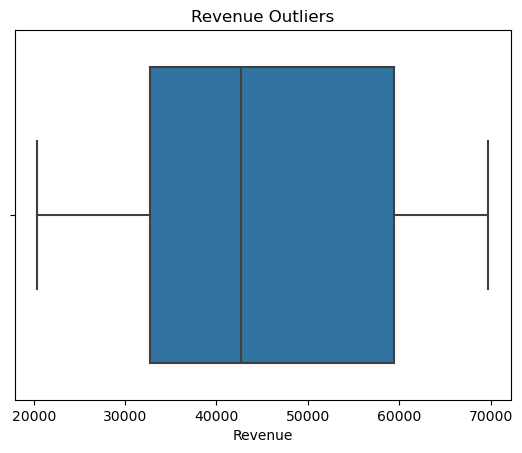

In [62]:
#هل فيه فروع شاذة (Outliers) في الإيرادات؟
sns.boxplot(x=df['Revenue'])
plt.title("Revenue Outliers")
plt.show()


In [63]:
region_profit = df.groupby('Sales Region')['Profit'].mean().sort_values(ascending=False)
region_profit


Sales Region
Region 2    42585.743902
Region 1    40380.161765
Name: Profit, dtype: float64

In [64]:
# التوسع الجديد ناجح في ولايات معينة أكتر من غيرها
new_store_profit = df[df['New Expansion'] == 'New'].groupby('State')['Profit'].mean().sort_values(ascending=False)
new_store_profit


State
Nevada            63559.000000
Ohio              59729.000000
New Mexico        52033.000000
Arizona           46337.200000
Oklahoma          45754.500000
North Carolina    45146.714286
Illinois          44968.333333
Georgia           43288.000000
Missouri          43173.000000
Texas             41903.357143
Wisconsin         41828.000000
Pennsylvania      41699.666667
Florida           41666.000000
Virginia          36759.000000
Louisiana         36400.666667
Maryland          35766.000000
California        33690.142857
New Jersey        32352.000000
New York          30263.000000
Name: Profit, dtype: float64

In [65]:
#ده يساعدك تحدد المدن اللي محتاجة دعم أو اللي تعتبر فرص قوية.
city_profit = df.groupby('City')['Profit'].mean().sort_values(ascending=False).head(10)
city_profit

City
Colorado Springs    66944.00
Miami               63834.00
Washington          61911.00
Memphis             61367.50
Omaha               61332.50
Brownsville         59473.00
San Francisco       58323.00
Overland Park       57018.00
Mesa                56519.00
Oklahoma City       53398.25
Name: Profit, dtype: float64

In [66]:

df['ROMS'] = df['Profit'] / df['Marketing Spend']
df

,Store ID,City,State,Sales Region,New Expansion,Marketing Spend,Revenue,Profit,ROMS
0,1,Peoria,Arizona,Region 2,Old,2601,48610,46009,17.688966
1,2,Midland,Texas,Region 2,Old,2727,45689,42962,15.754309
2,3,Spokane,Washington,Region 2,Old,2768,49554,46786,16.902457
3,4,Denton,Texas,Region 2,Old,2759,38284,35525,12.876042
4,5,Overland Park,Kansas,Region 2,Old,2869,59887,57018,19.873824
...,...,...,...,...,...,...,...,...,...
145,146,Paterson,New Jersey,Region 1,New,2251,34603,32352,14.372279
146,147,Brownsville,Texas,Region 2,New,3675,63148,59473,16.183129
147,148,Rockford,Illinois,Region 1,New,2648,43377,40729,15.381042
148,149,College Station,Texas,Region 2,New,2994,22457,19463,6.500668


In [67]:
df.to_csv("Data_analysis_after.csv", index=False)
